In [81]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

# EDA

In [82]:
df = pd.read_csv("IRIS.csv")

In [83]:
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


In [84]:
df.tail()

,sepal_length,sepal_width,petal_length,petal_width,species
145,6.7,3.0,5.2,2.3,Iris-virginica
146,6.3,2.5,5.0,1.9,Iris-virginica
147,6.5,3.0,5.2,2.0,Iris-virginica
148,6.2,3.4,5.4,2.3,Iris-virginica
149,5.9,3.0,5.1,1.8,Iris-virginica


In [85]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


In [86]:
df.describe()

,sepal_length,sepal_width,petal_length,petal_width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.054000,3.758667,1.198667
std,0.828066,0.433594,1.764420,0.763161
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [87]:
df.shape

(150, 5)

In [88]:
df.columns

Index(['sepal_length', 'sepal_width', 'petal_length', 'petal_width',
       'species'],
      dtype='object')

In [89]:
df.isnull().sum()

sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64

In [90]:
df.duplicated().sum()

np.int64(3)

In [91]:
df = df.drop_duplicates()

In [92]:
df.shape

(147, 5)

# Univariate EDA

In [93]:
df['species'].value_counts()

species
Iris-versicolor    50
Iris-virginica     49
Iris-setosa        48
Name: count, dtype: int64

<Axes: xlabel='species'>

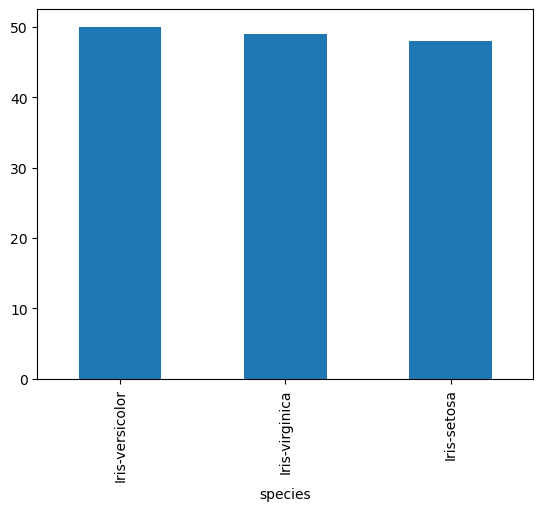

In [94]:
df['species'].value_counts().plot(kind = 'bar')

# Multivariate EDA

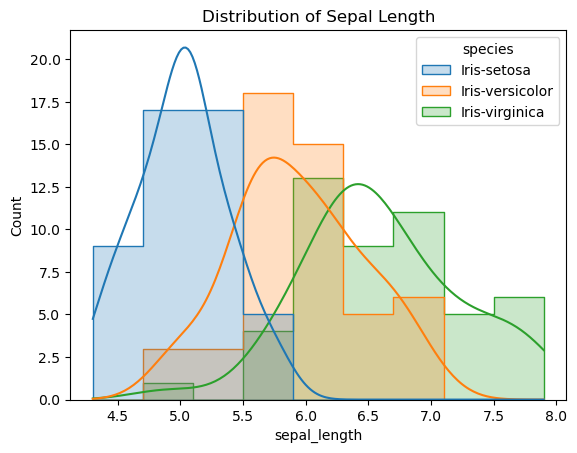

In [95]:
sns.histplot(data=df, x='sepal_length', hue='species', kde=True, element='step')
plt.title('Distribution of Sepal Length')
plt.show()

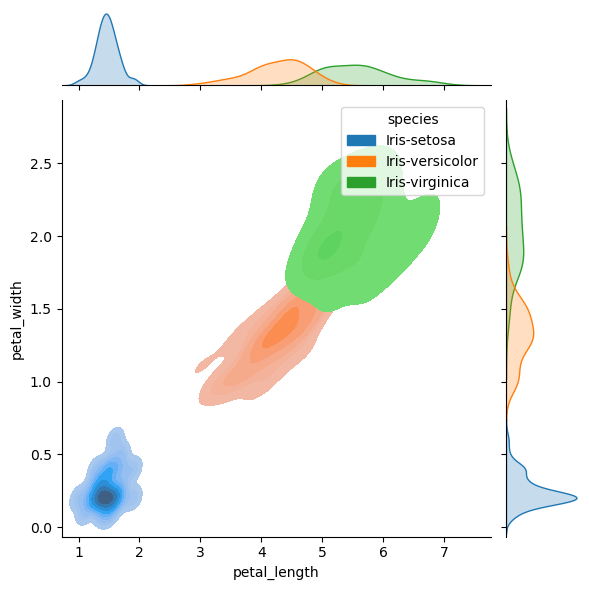

In [96]:
sns.jointplot(data=df, x='petal_length', y='petal_width', hue='species', kind='kde', fill=True)
plt.show()

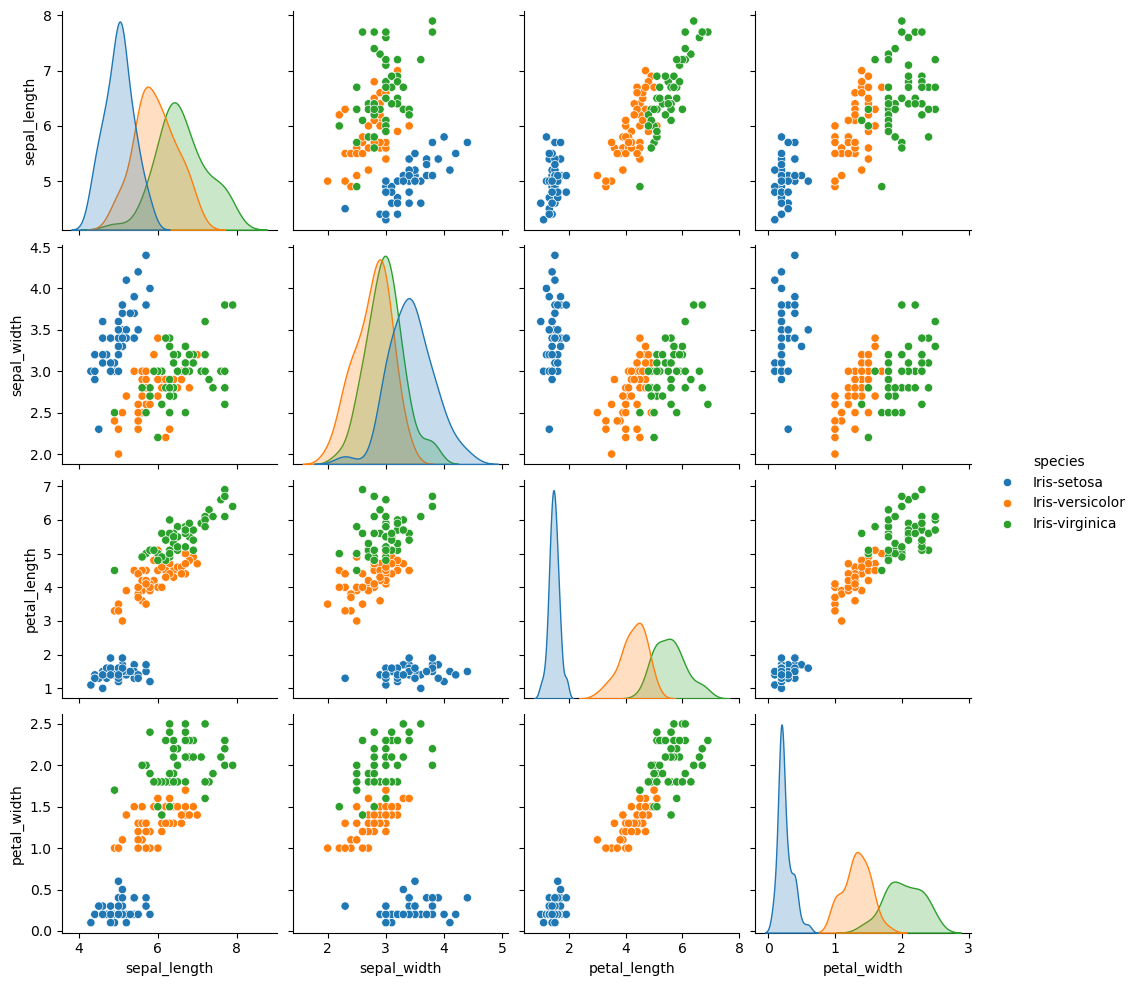

In [97]:
sns.pairplot(df,hue='species')

In [98]:
df["species"].value_counts()

species
Iris-versicolor    50
Iris-virginica     49
Iris-setosa        48
Name: count, dtype: int64

In [99]:
df["species"] = df["species"].map({"Iris-versicolor":1,"Iris-virginica":2,"Iris-setosa":3})

In [100]:
df.sample(5)

,sepal_length,sepal_width,petal_length,petal_width,species
59,5.2,2.7,3.9,1.4,1
33,5.5,4.2,1.4,0.2,3
91,6.1,3.0,4.6,1.4,1
122,7.7,2.8,6.7,2.0,2
46,5.1,3.8,1.6,0.2,3


In [101]:
df.columns

Index(['sepal_length', 'sepal_width', 'petal_length', 'petal_width',
       'species'],
      dtype='object')

# Model 

In [102]:
X = df.drop(columns = ["species"])
y = df["species"]

In [103]:
X

,sepal_length,sepal_width,petal_length,petal_width
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
...,...,...,...,...
145,6.7,3.0,5.2,2.3
146,6.3,2.5,5.0,1.9
147,6.5,3.0,5.2,2.0
148,6.2,3.4,5.4,2.3


In [104]:
y

0      3
1      3
2      3
3      3
4      3
      ..
145    2
146    2
147    2
148    2
149    2
Name: species, Length: 147, dtype: int64

In [105]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

In [106]:
X_train,X_test,y_train,y_test = train_test_split(X,y,random_state=42,test_size=0.2)

In [107]:
X_train.shape

(117, 4)

In [108]:
X_test.shape

(30, 4)

In [109]:
models = {
    "Logistic Regression": LogisticRegression(),
    "KNN": KNeighborsClassifier(),
    "Naive Bayes": GaussianNB(),
    "Decision Tree": DecisionTreeClassifier(),
    "SVM (RBF Kernel)": SVC(probability=True)
}

In [110]:
results = []

In [112]:
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='weighted')
    results.append({
        'Model': name,
        'Accuracy': round(acc, 4),
        'F1 Score': round(f1, 4)
    })

In [113]:
results

[{'Model': 'Logistic Regression', 'Accuracy': 0.9333, 'F1 Score': 0.9333},
 {'Model': 'KNN', 'Accuracy': 0.9333, 'F1 Score': 0.9333},
 {'Model': 'Naive Bayes', 'Accuracy': 0.9667, 'F1 Score': 0.9665},
 {'Model': 'Decision Tree', 'Accuracy': 0.9333, 'F1 Score': 0.9333},
 {'Model': 'SVM (RBF Kernel)', 'Accuracy': 0.9333, 'F1 Score': 0.9333}]

In [114]:
import joblib
joblib.dump(models['Naive Bayes'],'NB_model.pkl')
joblib.dump(X.columns.tolist(),'columns.pkl')

['columns.pkl']